In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder



df = pd.read_csv("./data/DSI_kickstarterscrape_dataset.csv", encoding="latin-1")


df = df[df['status'].isin(['successful', 'failed'])]
df['is_successful'] = (df['status'] == 'successful').astype(int)

# Parse reward levels into a count
df['reward_count'] = df['reward levels'].apply(lambda x: len(str(x).split(',')))

# Encode categorical columns
for col in ['category', 'subcategory']:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col].astype(str))

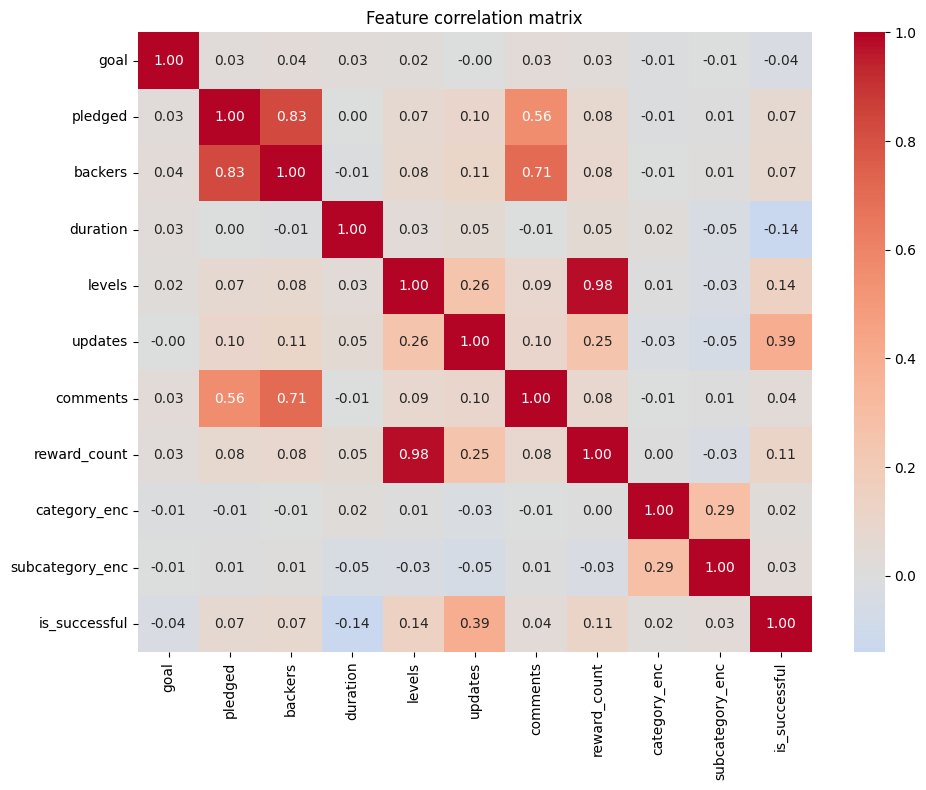

In [2]:
numeric_cols = ['goal', 'pledged', 'backers', 'duration',
                'levels', 'updates', 'comments', 'reward_count',
                'category_enc', 'subcategory_enc', 'is_successful']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

           feature  importance
1          backers    0.506909
0             goal    0.165964
4          updates    0.117091
5         comments    0.063073
2         duration    0.042980
8  subcategory_enc    0.031254
6     reward_count    0.026557
3           levels    0.023201
7     category_enc    0.022972


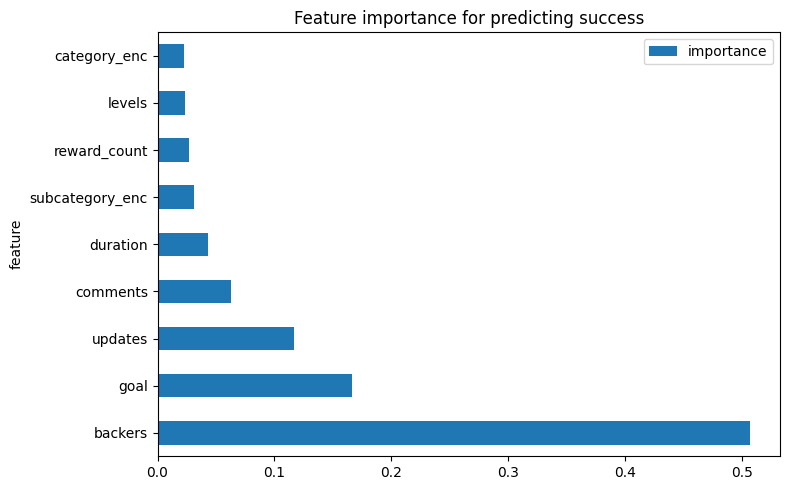

In [3]:
features = ['goal', 'backers', 'duration', 'levels',
            'updates', 'comments', 'reward_count',
            'category_enc', 'subcategory_enc']

X = df[features].fillna(0)
y = df['is_successful']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

importance_df.plot(x='feature', y='importance', kind='barh', figsize=(8, 5))
plt.title('Feature importance for predicting success')
plt.tight_layout()
plt.show()

In [4]:
# Take only the top N features by importance
top_features = importance_df.head(5)['feature'].tolist()

X_top = df[top_features].fillna(0)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_top, y, test_size=0.2, random_state=42)

rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)

print(classification_report(y_test2, rf2.predict(X_test2)))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3818
           1       0.92      0.94      0.93      4575

    accuracy                           0.93      8393
   macro avg       0.93      0.93      0.93      8393
weighted avg       0.93      0.93      0.93      8393

